# EAZY Performance Analysis

<p>The following code performs an analysis of the EAZY photometric redshift performanced with the following functions:</p>

- Comparsion with MSAEXP spectroscopic redshift
- Visualisation of select SEDs (WIP)
- Image retrieval for select targets (WIP)

#### zspec Performance Plot

σ_NMAD = 0.1004, Outlier fraction = 37.36%


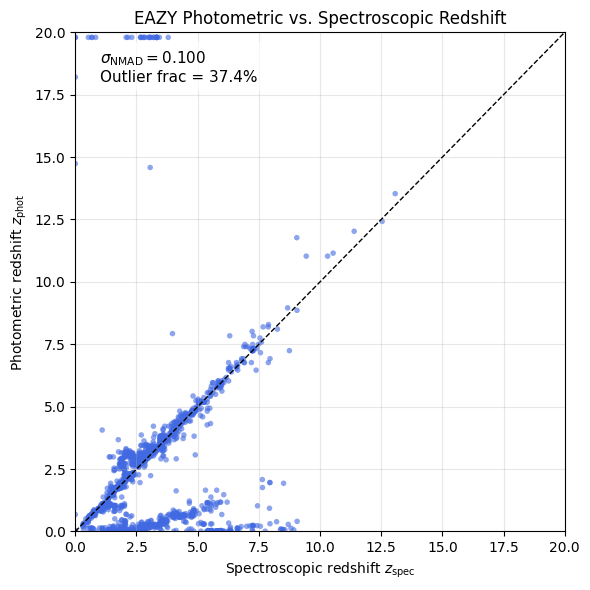

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table


def plot_zphot_zspec(zout_path, zmax=6, outlier_thresh=0.15):
    """
    Create a z_phot vs z_spec diagnostic plot similar to threedhst.eazyPy.zPhot_zSpec,
    including σ_NMAD and outlier fraction.

    Parameters
    ----------
    zout_path : str
        Path to the EAZY output file (photz.zout).
    save_as : str, optional
        Output filename for the plot (default: 'zphot_zspec.png').
    zmax : float, optional
        Maximum redshift for axes (default: 6).
    outlier_thresh : float, optional
        |Δz|/(1+z_spec) threshold for outliers (default: 0.15).
    """
    # --- Load EAZY output
    zout = Table.read(zout_path, format='ascii')

    # --- Identify columns automatically
    colnames = [c.lower() for c in zout.colnames]
    if 'z_spec' in colnames:
        zspec_col = zout.colnames[colnames.index('z_spec')]
    elif 'zspec' in colnames:
        zspec_col = zout.colnames[colnames.index('zspec')]
    else:
        raise ValueError("No spectroscopic redshift column found in .zout file.")

    if 'z_a' in colnames:
        zphot_col = zout.colnames[colnames.index('z_a')]
    elif 'z_phot' in colnames:
        zphot_col = zout.colnames[colnames.index('z_phot')]
    else:
        raise ValueError("No photometric redshift column (z_a / z_phot) found in .zout file.")

    # --- Extract arrays and clean NaNs
    zspec = np.array(zout[zspec_col])
    zphot = np.array(zout[zphot_col])
    mask1 = zspec >= 0
    mask2 = zphot >= 0

    mask = mask1 & mask2
    zspec, zphot = zspec[mask], zphot[mask]

    # --- Compute scatter metrics
    dz = (zphot - zspec) / (1 + zspec)
    dz = dz[np.isfinite(dz)]
    sigma_nmad = 1.48 * np.median(np.abs(dz - np.median(dz)))
    outlier_frac = np.mean(np.abs(dz) > outlier_thresh)

    # --- Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(zspec, zphot, s=16, alpha=0.6, color='royalblue', edgecolor='none', label='Data')
    plt.plot([0, zmax], [0, zmax], 'k--', lw=1, label='1:1')
    plt.xlabel(r'Spectroscopic redshift $z_{\rm spec}$')
    plt.ylabel(r'Photometric redshift $z_{\rm phot}$')
    plt.xlim(0, zmax)
    plt.ylim(0, zmax)
    plt.grid(alpha=0.3)

    # --- Annotate performance
    txt = (rf"$\sigma_{{\rm NMAD}} = {sigma_nmad:.3f}$" + "\n" +
           rf"Outlier frac = {outlier_frac*100:.1f}%")
    plt.text(0.05*zmax, 0.9*zmax, txt, fontsize=11, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.title('EAZY Photometric vs. Spectroscopic Redshift')
    plt.tight_layout()
    # plt.savefig(save_as, dpi=150)
    # plt.close()

    # print(f"✅ Plot saved to {save_as}")
    print(f"σ_NMAD = {sigma_nmad:.4f}, Outlier fraction = {outlier_frac*100:.2f}%")

plot_zphot_zspec('../inputs/OUTPUT/photz.zout', zmax=20)

#Delete the comment on line 1 and delete last line (incomplete)

In [15]:
RUN_NAME = 'GOODS-S'

cat_path = f'../inputs/{RUN_NAME}_photometry.cat'
cat = Table.read(cat_path, format='ascii')

cat

id,f_nircam_f090w,e_nircam_f090w,f_wfc3-ir_f105w,e_wfc3-ir_f105w,f_wfc3-ir_f110w,e_wfc3-ir_f110w,f_nircam_f115w,e_nircam_f115w,f_niriss_f115w,e_niriss_f115w,f_wfc3-ir_f125w,e_wfc3-ir_f125w,f_wfc3-ir_f140w,e_wfc3-ir_f140w,f_nircam_f150w,e_nircam_f150w,f_niriss_f150w,e_niriss_f150w,f_wfc3-ir_f160w,e_wfc3-ir_f160w,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_niriss_f200w,e_niriss_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f335m,e_nircam_f335m,f_wfc3-uvis_f350lp,e_wfc3-uvis_f350lp,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f475w,e_acs_f475w,f_nircam_f480m,e_nircam_f480m,f_acs_f606w,e_acs_f606w,f_wfc3-uvis_f606w,e_wfc3-uvis_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_wfc3-uvis_f814w,e_wfc3-uvis_f814w,f_acs_f850lp,e_acs_f850lp,f_wfc3-uvis_f850lp,e_wfc3-uvis_f850lp,z_spec
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
51,-99.0,10000000000.0,0.0593475,0.007747864,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.05836483,0.005813961,0.07454174,0.01529728,-99.0,10000000000.0,-99.0,10000000000.0,0.07680882,0.008678746,0.155576,0.004910302,-99.0,10000000000.0,-99.0,10000000000.0,0.1186988,0.005949958,-99.0,10000000000.0,-99.0,10000000000.0,0.04048118,0.003438643,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.02121764,0.003075538,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.05556428,0.001915305,-99.0,10000000000.0,0.057534,0.004491354,0.0670911,0.001731345,-99.0,10000000000.0,0.06828083,0.004686326,-99.0,10000000000.0,2.8997
70,-99.0,10000000000.0,0.01354786,0.007710654,0.01639714,0.004596723,-99.0,10000000000.0,-99.0,10000000000.0,0.02268065,0.004125744,0.03173412,0.01544646,-99.0,10000000000.0,-99.0,10000000000.0,0.02316182,0.005106059,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.0194116,0.002879063,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.01309401,0.001772172,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.02514552,0.002325826,-99.0,10000000000.0,0.02807122,0.005344385,0.0318174,0.001566007,-99.0,10000000000.0,0.02745068,0.004666157,-99.0,10000000000.0,3.0992
161,-99.0,10000000000.0,0.04325883,0.007784499,0.04980086,0.004766304,-99.0,10000000000.0,-99.0,10000000000.0,0.05633038,0.004780914,0.06612275,0.01557286,-99.0,10000000000.0,-99.0,10000000000.0,0.1200044,0.006138493,0.2241059,0.003756392,-99.0,10000000000.0,-99.0,10000000000.0,0.2438887,0.004796057,-99.0,10000000000.0,-99.0,10000000000.0,0.01667261,0.003198988,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.008990909,0.001841468,0.5182109,0.00537357,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.01992272,0.001908054,-99.0,10000000000.0,0.0264787,0.00460572,0.03409667,0.001679477,-99.0,10000000000.0,0.0365191,0.004624361,-99.0,10000000000.0,2.701
162,-99.0,10000000000.0,0.2544747,0.008272586,0.2781704,0.004947456,-99.0,10000000000.0,-99.0,10000000000.0,0.3152914,0.004981153,0.3086511,0.01510506,-99.0,10000000000.0,-99.0,10000000000.0,0.4888257,0.00622609,0.4535697,0.003849984,-99.0,10000000000.0,-99.0,10000000000.0,0.7043064,0.00513045,-99.0,10000000000.0,-99.0,10000000000.0,0.1977301,0.003311004,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.1427426,0.002009383,0.5049547,0.0053151

In [16]:
zout_path = '../inputs/OUTPUT/photz.zout'
zout = Table.read(zout_path, format='ascii')
zout

id,z_spec,z_a,z_m1,chi_a,l68,u68,l95,u95,l99,u99,nfilt,q_z,z_peak,peak_prob,z_mc
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
51,2.8997,3.493,3.535,43.03912,3.437,3.655,3.393,3.723,3.383,3.747,12,1.76119,3.5343,0.999,3.5048
70,3.0992,0.445,1.583,18.02155,0.358,3.358,0.191,3.494,0.101,3.606,11,1059070000.0,0.4442,0.601,0.2833
161,2.701,3.108,3.102,9.225253,3.025,3.187,2.901,3.24,2.826,3.292,14,0.390721,3.1023,0.999,3.1467
162,2.3445,3.108,3.119,292.6653,3.064,3.167,3.05,3.204,3.04,3.211,14,4.55549,3.1139,0.87,3.1211
168,4.0408,4.216,4.188,61.28473,4.105,4.272,4.0,4.292,3.937,4.321,14,2.25445,4.1875,0.997,4.2586
170,4.8214,4.936,4.947,18.65328,4.85,5.055,4.734,5.137,4.63,5.23,12,1.24302,4.9467,0.998,4.9316
183,1.9627,2.503,2.281,16.82446,1.84,2.591,1.685,2.68,1.617,2.767,12,2.17503,2.5392,0.619,2.5242
191,2.9193,3.448,3.454,34.65374,3.396,3.51,3.365,3.556,3.249,3.605,12,1.37387,3.4545,0.997,3.4077
194,3.5979,3.914,3.908,64.08363,3.827,3.984,3.781,4.075,3.725,4.134,14,2.37795,3.906,0.988,3.9382


In [ ]:
diagnostic_tab = zout['id', 'z_spec', 'z_a']
diagnostic_tab['delta_z'] = (zout['z_a'] - zout['z_spec']) / (1 + zout['z_spec'])
len_diagnostic = len(diagnostic_tab) # Account for mismatch from EAZY termination issue - FIX IF POSSIBLE

for col_name in cat.colnames:
    if col_name.startswith('f_'):
        diagnostic_tab[col_name] = cat[col_name][0:len_diagnostic]

diagnostic_tab

id,z_spec,z_a,delta_z,f_nircam_f090w,f_wfc3-ir_f105w,f_wfc3-ir_f110w,f_nircam_f115w,f_niriss_f115w,f_wfc3-ir_f125w,f_wfc3-ir_f140w,f_nircam_f150w,f_niriss_f150w,f_wfc3-ir_f160w,f_nircam_f182m,f_nircam_f200w,f_niriss_f200w,f_nircam_f210m,f_nircam_f277w,f_nircam_f335m,f_wfc3-uvis_f350lp,f_nircam_f356w,f_nircam_f410m,f_nircam_f430m,f_acs_f435w,f_nircam_f444w,f_nircam_f460m,f_acs_f475w,f_nircam_f480m,f_acs_f606w,f_wfc3-uvis_f606w,f_acs_f775w,f_acs_f814w,f_wfc3-uvis_f814w,f_acs_f850lp,f_wfc3-uvis_f850lp
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
51,2.8997,3.493,0.15213990819806644,-99.0,0.0593475,-99.0,-99.0,-99.0,0.05836483,0.07454174,-99.0,-99.0,0.07680882,0.155576,-99.0,-99.0,0.1186988,-99.0,-99.0,0.04048118,-99.0,-99.0,-99.0,0.02121764,-99.0,-99.0,-99.0,-99.0,0.05556428,-99.0,0.057534,0.0670911,-99.0,0.06828083,-99.0
70,3.0992,0.445,-0.6474921935987511,-99.0,0.01354786,0.01639714,-99.0,-99.0,0.02268065,0.03173412,-99.0,-99.0,0.02316182,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,0.0194116,-99.0,-99.0,-99.0,0.01309401,-99.0,-99.0,-99.0,-99.0,0.02514552,-99.0,0.02807122,0.0318174,-99.0,0.02745068,-99.0
161,2.701,3.108,0.10997027830316132,-99.0,0.04325883,0.04980086,-99.0,-99.0,0.05633038,0.06612275,-99.0,-99.0,0.1200044,0.2241059,-99.0,-99.0,0.2438887,-99.0,-99.0,0.01667261,-99.0,-99.0,-99.0,0.008990909,0.5182109,-99.0,-99.0,-99.0,0.01992272,-99.0,0.0264787,0.03409667,-99.0,0.0365191,-99.0
162,2.3445,3.108,0.22828524443115564,-99.0,0.2544747,0.2781704,-99.0,-99.0,0.3152914,0.3086511,-99.0,-99.0,0.4888257,0.4535697,-99.0,-99.0,0.7043064,-99.0,-99.0,0.1977301,-99.0,-99.0,-99.0,0.1427426,0.5049547,-99.0,-99.0,-99.0,0.2393754,-99.0,0.2617437,0.2642032,-99.0,0.2609116,-99.0
168,4.0408,4.216,0.034756387874940536,-99.0,0.05270948,0.06549781,-99.0,-99.0,0.06364084,0.08045479,-99.0,-99.0,0.05719825,0.1174852,-99.0,-99.0,0.1299137,-99.0,-99.0,0.02342756,-99.0,-99.0,-99.0,-0.001631611,0.1362845,-99.0,-99.0,-99.0,0.03000292,-99.0,0.05811312,0.06342576,-99.0,0.0716605,-99.0
170,4.8214,4.936,0.019685986188889316,-99.0,0.0361352,-99.0,-99.0,-99.0,0.02755087,0.004017721,-99.0,-99.0,0.02311826,0.0369616,-99.0,-99.0,0.03010559,-99.0,-99.0,0.01311416,-99.0,-99.0,-99.0,-0.0009014721,-99.0,-99.0,-99.0,-99.0,0.004447313,-99.0,0.03322518,0.02982282,-99.0,0.02138712,-99.0
183,1.9627,2.503,0.18236743510986608,-99.0,0.02438975,-99.0,-99.0,-99.0,0.03285454,0.06001931,-99.0,-99.0,0.03541372,0.05224995,-99.0,-99.0,0.03973646,-99.0,-99.0,0.02317707,-99.0,-99.0,-99.0,0.0284589,-99.0,-99.0,-99.0,-99.0,0.0213931,-99.0,0.02349806,0.01955534,-99.0,0.01704335,-99.0
191,2.9193,3.448,0.13489653764702886,-99.0,-99.0,-99.0,-99.0,-99.0,0.04520249,0.05306789,-99.0,-99.0,0.06233767,0.1189483,-99.0,-99.0,0.1045323,-99.0,-99.0,0.04166504,-99.0,-99.0,-99.0,0.0207151,-99.0,-99.0,-99.0,-99.0,0.0466993,-99.0,0.0592609,0.05358766,-99.0,0.04949006,0.0208082
194,3.5979,3.914,0.06874877661541139,-99.0,0.07335001,0.09367092,-99.0,-99.0,0.09954343,0.1007047,-99.0,-99.0,0.1089333,0.1952325,-99.0,-99.0,0.211903,-99.0,-99.0,0.03499366,-99.0,-99.0,-99.0,0.00445974,0.2756408,-99.0,-99.0,-99.0,0.04127456,-99.0,0.08618872,0.0890764,-99.0,0.09389149,-99.0


#### SED Visualization

In [ ]:
from pathlib import Path

def pivot_wavelength(wave, throughput):
    """
    Compute pivot wavelength.
    
    Parameters
    ----------
    wave : array
        Wavelength array (same units throughout, e.g. Angstrom or micron)
    throughput : array
        Dimensionless system throughput
    
    Returns
    -------
    lambda_pivot : float
        Pivot wavelength in same units as `wave`
    """
    num = np.trapz(wave * throughput, wave)
    den = np.trapz(throughput / wave, wave)
    return np.sqrt(num / den)

# Step 1 - Identify pivot wavelengths for each filter
filter_dirs = {
    "nircam": Path("../throughputs/nircam_throughputs"),
    "niriss": Path("../throughputs/niriss_throughputs"),
    "wfc3-ir":   Path("../throughputs/wfc3-ir_throughputs"),
    "wfc3-uvis": Path("../throughputs/wfc3-uvis_throughputs"),
    "acs":    Path("../throughputs/acs_throughputs"),
}

pivot_list = []

for filter_name, filter_dir in filter_dirs.items():
    for file in filter_dir.glob("*.txt"):
        data = np.genfromtxt(file, names=None, dtype=float, invalid_raise=False)
        wave = data[:, 0]  # Wavelength
        if "wfc3" in filter_name or "acs" in filter_name:
            throughput = data[:, 1]  # Throughput for WFC3/ACS
        if filter_name == "nircam":
            throughput = data[:, 1] * 1e4  # Throughput
        if filter_name == "niriss":
            throughput = data[:, 1] * data[:, 2] * 1e4  # Throughput
        lambda_pivot = pivot_wavelength(wave, throughput)
        pivot_list.append(lambda_pivot)

In [10]:
pivot_list

[('nircam', 0.7047111391619164),
 ('nircam', 3.623338280101858),
 ('nircam', 1.8452162232046974),
 ('nircam', 1.1540782060233898),
 ('nircam', 2.9960861512933863),
 ('nircam', 4.816546417311176),
 ('nircam', 1.405342070452686),
 ('nircam', 2.121246540932387),
 ('nircam', 1.9876006306614384),
 ('nircam', 4.053118871596095),
 ('nircam', 2.7762299040374514),
 ('nircam', 1.671778037365018),
 ('nircam', 4.707783428350512),
 ('nircam', 1.5008986492444132),
 ('nircam', 4.654407017667469),
 ('nircam', 2.1287028508185615),
 ('nircam', 4.281295459815133),
 ('nircam', 1.8740525619694932),
 ('nircam', 4.082988273666916),
 ('nircam', 4.401743343383445),
 ('nircam', 1.6445086994387776),
 ('nircam', 3.2467831434647785),
 ('nircam', 4.629616879154382),
 ('nircam', 3.3622534099039454),
 ('nircam', 2.5031347408094615),
 ('nircam', 3.2367559716665784),
 ('nircam', 3.5654890200017375),
 ('nircam', 0.9024004322715571),
 ('nircam', 2.0955948794052883),
 ('nircam', 1.6272250312198802),
 ('niriss', nan),
 ('n